In [5]:
import os
import sys

import numpy as np
import pandas as pd
from statistics import mean
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Add project root (one level above notebooks/) to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils import dimensionality_reduction_utils as dr_utils

In [6]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Features: {feature_names}")
print(f"TargetNames: {target_names}")

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
TargetNames: ['malignant' 'benign']


<div class='alert alert-info'>The Breast Cancer Wisconsin (Diagnostic) dataset contains features computed from digitized images of fine needle aspirate (FNA) of breast masses, describing characteristics of cell nuclei present in the images, used to predict whether a breast mass is benign or malignant.

Features

| Feature Name     | Description                                        | Value Range            |
|------------------|----------------------------------------------------|------------------------| 
| Radius           | Mean of distances from center to points on perimeter | Continuous           |
| Texture          | Standard deviation of gray-scale values            | Continuous             |
| Perimeter        | Perimeter of the cell nucleus                      | Continuous             |
| Area             | Area of the cell nucleus                           | Continuous             |
| Smoothness       | Local variation in radius lengths                  | Continuous             |
| Compactness      | (Perimeter² / Area) - 1.0                          | Continuous             |
| Concavity        | Severity of concave portions of the contour        | Continuous             |
| Concave points   | Number of concave portions of the contour          | Continuous             |
| Symmetry         | Symmetry of the cell nucleus                       | Continuous             |
| Fractal dimension| "Coastline approximation" - 1                      | Continuous             |

For each of the 10 real-valued features (radius through fractal dimension), three values are computed
* Mean
* Standard Error
* Worst or largest mean
</div>

In [7]:
df= pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [8]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Class Distribution: \n0->malignant\n1->benign\n{df['target'].value_counts()}")

Dataset shape: (569, 31)
Number of samples: 569
Class Distribution: 
0->malignant
1->benign
target
1    357
0    212
Name: count, dtype: int64


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

The dataset contains 569 samples with 31 continuous numerical features that describe various characteristics of cell nuclei, such as radius, texture, perimeter, and area, measured as mean, standard error, and worst values. All columns are complete with no missing values (569 non-null), and the data type is float64, making it clean and directly usable for analysis.

In [11]:
print(f"Dataset Statistics:")
print(df.describe().T)

Dataset Statistics:
                         count        mean         std         min  \
mean radius              569.0   14.127292    3.524049    6.981000   
mean texture             569.0   19.289649    4.301036    9.710000   
mean perimeter           569.0   91.969033   24.298981   43.790000   
mean area                569.0  654.889104  351.914129  143.500000   
mean smoothness          569.0    0.096360    0.014064    0.052630   
mean compactness         569.0    0.104341    0.052813    0.019380   
mean concavity           569.0    0.088799    0.079720    0.000000   
mean concave points      569.0    0.048919    0.038803    0.000000   
mean symmetry            569.0    0.181162    0.027414    0.106000   
mean fractal dimension   569.0    0.062798    0.007060    0.049960   
radius error             569.0    0.405172    0.277313    0.111500   
texture error            569.0    1.216853    0.551648    0.360200   
perimeter error          569.0    2.866059    2.021855    0.757000   


In [12]:
df[y == 0].head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


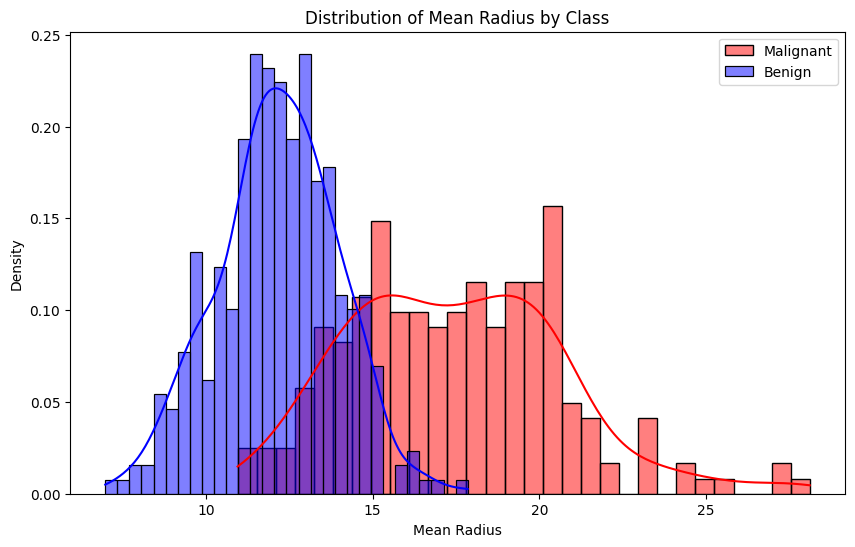

In [13]:
# Visualize the distribution of the 'mean radius' feature for both classes
plt.figure(figsize=(10, 6))
sns.histplot(df[df['target'] == 0]['mean radius'], color='red', label='Malignant', kde=True, stat="density", bins=30)
sns.histplot(df[df['target'] == 1]['mean radius'], color='blue', label='Benign', kde=True, stat="density", bins=30)
plt.title('Distribution of Mean Radius by Class')
plt.xlabel('Mean Radius')
plt.ylabel('Density')   
plt.legend()
plt.show()

IN the above plot, we can see that the 'mean radius' feature has a different distribution for malignant and benign classes. Malignant samples tend to have a higher mean radius compared to benign samples. This suggests that 'mean radius' could be a useful feature for distinguishing between the two classes. We can further explore other features to see if they also show similar patterns of separation between the classes.

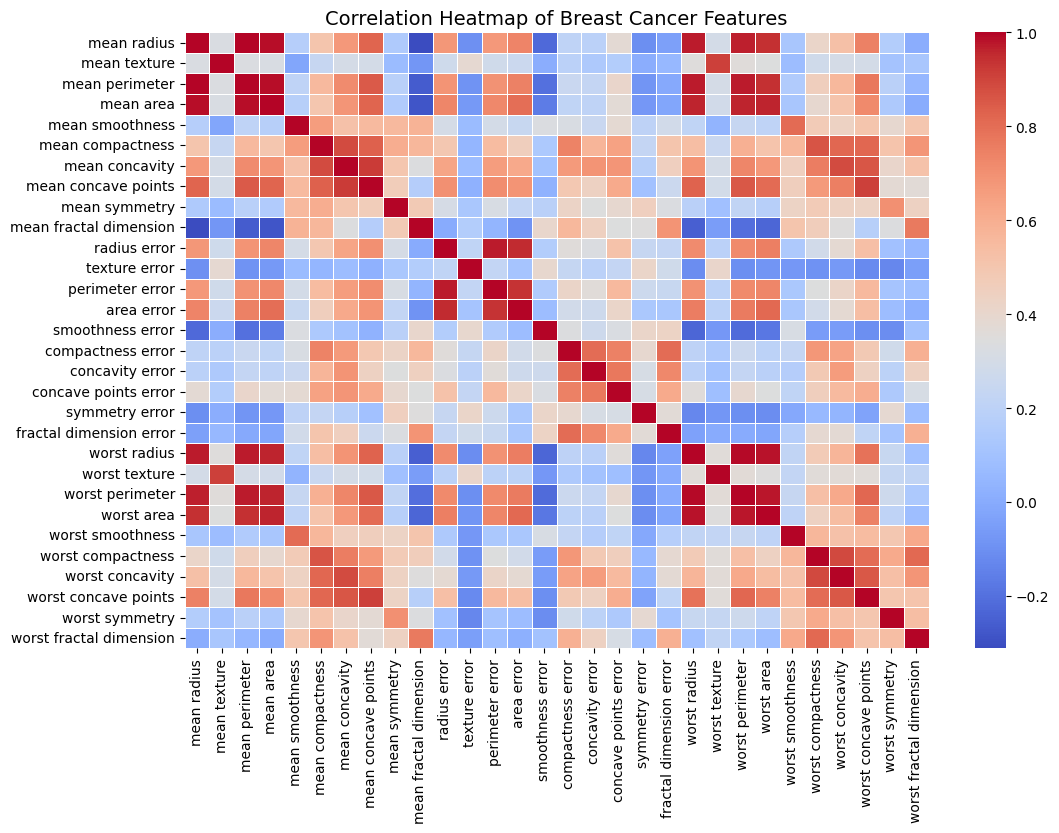

In [14]:
#Compute the correlation matrix
corr = df.iloc[:,:-1].corr()
# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Draw the heatmap
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Breast Cancer Features", fontsize=14)
plt.show()

From the correlation matrix above, we can identify clusters of highly correlated features. For instance, features related to the mean values (e.g., radius_mean, texture_mean, perimeter_mean) tend to be highly correlated with each other. Similarly, features related to the error and worst values (e.g.,radius_error,texture_error,perimeter_error, radius_worst, texture_worst, perimeter_worst) also show strong correlations among themselves. This indicates that these groups of features may provide redundant information, and we might consider dimensionality reduction techniques like PCA to reduce redundancy while retaining important information for classification tasks.

<div class='alert alert-success'> Apply PCA to reduce the dimensionality of the dataset while retaining the most important features </div>

<div class='alert alert-success'> Step 1 : Standardize the Data </div>

Standard Deviation formula:

![image.jpg](../images/Std_deviation.jpg)

Reference: https://www.cuemath.com/data/standard-deviation/

Standardization formula:

![image.jpg](../images/standardization.jpg)

In [ ]:
std_deviation = dr_utils.calculate_standard_deviation(X)
X_mean = np.mean(X, axis=0)
X_scaled = (X - X_mean) / std_deviation
print(f"Standard Deviation: {std_deviation}")
print(f"Features Mean:\n {X_mean}")    
print(f"Scaled Data:\n {X_scaled}")  

Standard Deviation: [3.52095076e+00 4.29725464e+00 2.42776193e+01 3.51604754e+02
 1.40517641e-02 5.27663291e-02 7.96497253e-02 3.87687325e-02
 2.73901809e-02 7.05415588e-03 2.77068942e-01 5.51163427e-01
 2.02007710e+00 4.54510134e+01 2.99987837e-03 1.78924359e-02
 3.01595231e-02 6.16486075e-03 8.25910439e-03 2.64374475e-03
 4.82899258e+00 6.14085432e+00 3.35730016e+01 5.68856459e+02
 2.28123569e-02 1.57198171e-01 2.08440875e-01 6.56745545e-02
 6.18130785e-02 1.80453893e-02]
Features Mean:
 [1.41272917e+01 1.92896485e+01 9.19690334e+01 6.54889104e+02
 9.63602812e-02 1.04340984e-01 8.87993158e-02 4.89191459e-02
 1.81161863e-01 6.27976098e-02 4.05172056e-01 1.21685343e+00
 2.86605923e+00 4.03370791e+01 7.04097891e-03 2.54781388e-02
 3.18937163e-02 1.17961371e-02 2.05422988e-02 3.79490387e-03
 1.62691898e+01 2.56772232e+01 1.07261213e+02 8.80583128e+02
 1.32368594e-01 2.54265044e-01 2.72188483e-01 1.14606223e-01
 2.90075571e-01 8.39458172e-02]
Scaled Data:
 [[ 1.09706398 -2.07333501  1.269

In [16]:
# To compare with library function
X_scaled_lib = StandardScaler().fit_transform(X)
print(f"Library Scaled Data: {X_scaled_lib}") 

Library Scaled Data: [[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]


<div class='alert alert-success'> Step2 : Compute the covariance matrix of the standardized data </div>

In [17]:
cov_matrix = dr_utils.calculate_covariance_matrix(X_scaled)
print(f"Covariance Matrix:\n {cov_matrix}")

Covariance Matrix:
 [[ 1.00176056e+00  3.24351929e-01  9.99612069e-01  9.89095475e-01
   1.70881506e-01  5.07014640e-01  6.77955036e-01  8.23976636e-01
   1.48001350e-01 -3.12179472e-01  6.80285970e-01 -9.74887767e-02
   6.75358538e-01  7.37159198e-01 -2.22992026e-01  2.06362656e-01
   1.94545531e-01  3.76831225e-01 -1.04504545e-01 -4.27163418e-02
   9.71245907e-01  2.97530545e-01  9.66835698e-01  9.42739295e-01
   1.19826732e-01  4.14190751e-01  5.27839123e-01  7.45524434e-01
   1.64241985e-01  7.07832563e-03]
 [ 3.24351929e-01  1.00176056e+00  3.30113223e-01  3.21650988e-01
  -2.34296930e-02  2.37118951e-01  3.02950254e-01  2.93980713e-01
   7.15266864e-02 -7.65717560e-02  2.76354360e-01  3.87037830e-01
   2.82169018e-01  2.60302460e-01  6.62542133e-03  1.92312595e-01
   1.43545353e-01  1.64139495e-01  9.14323671e-03  5.45533955e-02
   3.53193674e-01  9.13650301e-01  3.58669926e-01  3.44150782e-01
   7.76398084e-02  2.78318729e-01  3.01555198e-01  2.95835766e-01
   1.05192783e-01  1.

<div class='alert alert-success'> Step3 : compute eigenvalues and eigenvectors of the covariance matrix </div>

In [18]:
eigenvalues, eigenvectors = dr_utils.calculate_eigen_decompostion(cov_matrix)
print(f"Eigenvalues:\n {eigenvalues}")
print(f"EigenVectors:\n {eigenvectors}")

Eigenvalues:
 [1.33049908e+01 5.70137460e+00 2.82291016e+00 1.98412752e+00
 1.65163324e+00 1.20948224e+00 6.76408882e-01 4.77456255e-01
 4.17628782e-01 3.51310875e-01 2.94433153e-01 2.61621161e-01
 2.41782421e-01 1.57286149e-01 9.43006956e-02 8.00034045e-02
 5.95036135e-02 5.27114222e-02 4.95647002e-02 3.12142606e-02
 3.00256631e-02 2.74877113e-02 2.43836914e-02 1.80867940e-02
 1.55085271e-02 8.19203712e-03 6.91261258e-03 1.59213600e-03
 7.50121413e-04 1.33279057e-04]
EigenVectors:
 [[ 2.18902444e-01 -2.33857132e-01 -8.53124284e-03  4.14089623e-02
  -3.77863538e-02  1.87407904e-02  1.24088340e-01  7.45229622e-03
  -2.23109764e-01  9.54864432e-02  4.14714866e-02  5.10674568e-02
   1.19672116e-02 -5.95061348e-02  5.11187749e-02 -1.50583883e-01
   2.02924255e-01  1.46712338e-01 -2.25384659e-01 -4.96986642e-02
   6.85700057e-02 -7.29289034e-02  9.85526942e-02 -1.82579441e-01
   1.92264989e-02  1.29476396e-01 -1.31526670e-01 -2.11194013e-01
   2.11460455e-01 -7.02414091e-01]
 [ 1.03724578e-

In [19]:
explained_vairance_ratio = eigenvalues / np.sum(eigenvalues)
print(f"Explained Variance Ratio: {explained_vairance_ratio}")

Explained Variance Ratio: [4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


<div class='alert alert-success'> Step 4: select the top k eigenvalues and their corresponding eigenvectors to form a new feature space </div>

In [20]:
# number of components = 1
print(f"\nOriginal Dimensions: 30D")
print(f"Reduced Dimensions: 1D")
print(f"Explained Variance Ratio: {explained_vairance_ratio[0] * 100:.2f}%")
print(f"Variance Lost: {100 - explained_vairance_ratio[0]*100:.2f}%")



Original Dimensions: 30D
Reduced Dimensions: 1D
Explained Variance Ratio: 44.27%
Variance Lost: 55.73%


The original dataset had 30 features (30D), and when we reduced it to 1 principal component (1D). This first component captures 44.27% of the total variance in the data, meaning it explains almost half of the information present in the original 30-dimensional space. However, it also means that 55.73% of the variance is lost, so one component alone is not sufficient to represent the dataset accurately. In other words, while the first component is clearly important and holds the most dominant pattern in the data, additional components are necessary to capture the majority of the information.

In [21]:
selected_vectors = eigenvectors[:,0]
print(f"Selected Eigenvectors for 1D:\n{selected_vectors}")

Selected Eigenvectors for 1D:
[0.21890244 0.10372458 0.22753729 0.22099499 0.14258969 0.23928535
 0.25840048 0.26085376 0.13816696 0.06436335 0.20597878 0.01742803
 0.21132592 0.20286964 0.01453145 0.17039345 0.15358979 0.1834174
 0.04249842 0.10256832 0.22799663 0.10446933 0.23663968 0.22487053
 0.12795256 0.21009588 0.22876753 0.25088597 0.12290456 0.13178394]


In [22]:
X_pca_1d = X_scaled @ selected_vectors

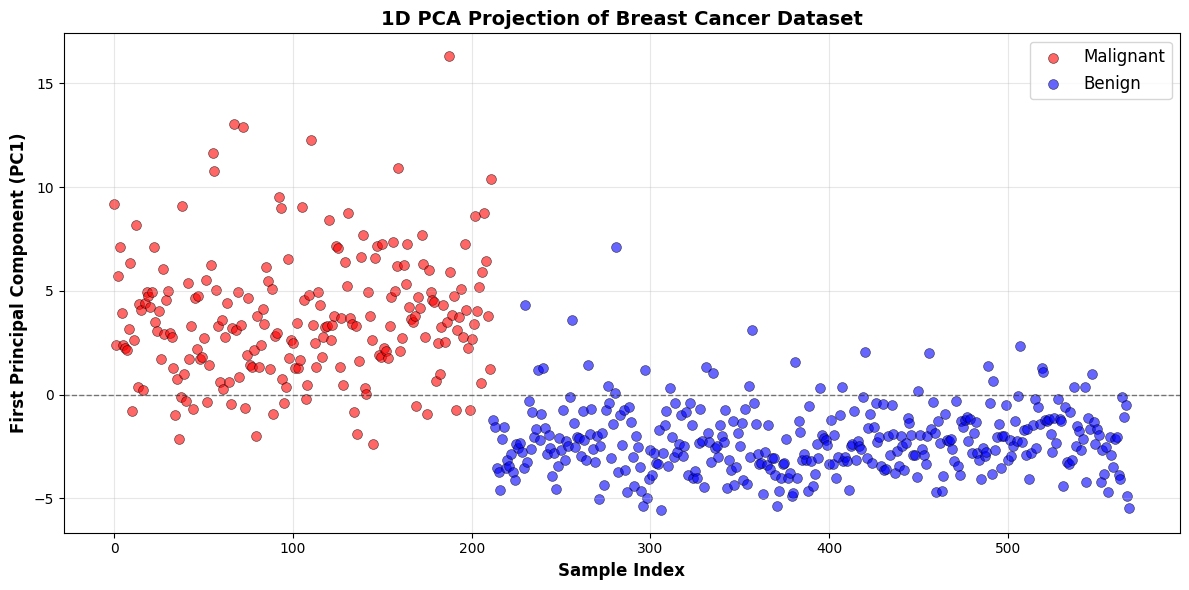

In [23]:
# Visualize 1D PCA
fig, ax = plt.subplots(figsize=(12, 6))

# Plot malignant samples
malignant_mask = y == 0
benign_mask = y == 1

ax.scatter(range(np.sum(malignant_mask)), X_pca_1d[malignant_mask], 
           c='red', label='Malignant', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.scatter(range(np.sum(malignant_mask), len(X_pca_1d)), X_pca_1d[benign_mask], 
           c='blue', label='Benign', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax.set_ylabel('First Principal Component (PC1)', fontsize=12, fontweight='bold')
ax.set_title('1D PCA Projection of Breast Cancer Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

<div class='alert alert-info'>
<u>1D PCA Observations</u>:

From the above <b>1D PCA projection</b>, We can can observe that <b>benign tumors (blue)</b> tend to cluster on the <i><b>negative side</b></i> of the first principal component (PC1), while <b>malignant tumors (red) </b>cluster on the <i><b>positive side</b></i>.This separation arises because features like mean radius, perimeter, and area (which are typically larger for malignant cells) likely contribute positively to PC1, while benign samples have lower values in these directions. Thus, PC1 effectively captures variance in the features that differentiate between benign and malignant tumors. While some overlap remains, indicating that a single principal component does not completely separate them. Overall, PC1 has effectively reduced the dimensionality while retaining key discriminative information(patterns in the data).</div>

In [24]:
# number of components = 2
X_pca_2d = X_scaled @ eigenvectors[:, :2]

In [25]:
print(f"\nOriginal Dimensions: 30D")
print(f"Reduced Dimensions: 2D")
print(f"Variance Explained:")
print(f"  - PC1: {explained_vairance_ratio[0]*100:.2f}%")
print(f"  - PC2: {explained_vairance_ratio[1]*100:.2f}%")
print(f"  - Total: {(explained_vairance_ratio[0] + explained_vairance_ratio[1])*100:.2f}%")


Original Dimensions: 30D
Reduced Dimensions: 2D
Variance Explained:
  - PC1: 44.27%
  - PC2: 18.97%
  - Total: 63.24%


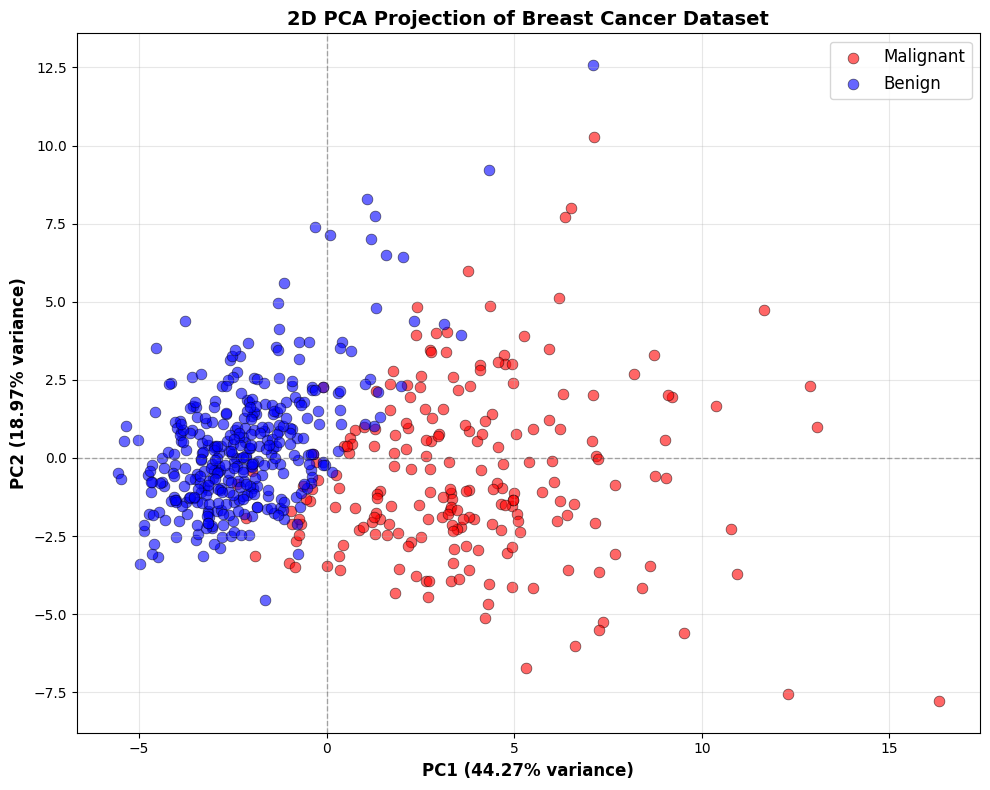

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter_malignant = ax.scatter(X_pca_2d[malignant_mask, 0], X_pca_2d[malignant_mask, 1],c='red', label='Malignant', alpha=0.6, s=60, 
                               edgecolors='black', linewidth=0.5)
scatter_benign = ax.scatter(X_pca_2d[benign_mask, 0], X_pca_2d[benign_mask, 1],c='blue', label='Benign', alpha=0.6, s=60, edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({explained_vairance_ratio[0]*100:.2f}% variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({explained_vairance_ratio[1]*100:.2f}% variance)', fontsize=12, fontweight='bold')
ax.set_title('2D PCA Projection of Breast Cancer Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

<div class='alert alert-info'>
<u>2D PCA Observations</u>:

From the above <b>2D PCA Projections</b>, We can observe that there is a <b>clearer separation</b> between the <b>malignant (red) and benign (blue)</b> classes compared to the <b>1D projection</b>. The two principal components (PC1 and PC2) together capture approximately 63% of the total variance in the data, which helps in better distinguishing between the two classes. Benign samples concentrated in the left-center region (PC1 = -5 to 5, PC2 = -2.5 to 7.5) and malignant samples spreading toward the right and upper-right (PC1 = 0 to 15, PC2 = -5 to 10). However, some overlap still exists, indicating that while PCA has imporved class separability, it is not perfect. Overall, the 2d PCA projection reveals a stronger class distinction than the 1D view.
</div>

In [27]:
# number of components = 3
X_pca_3d = X_scaled @ eigenvectors[:, :3]

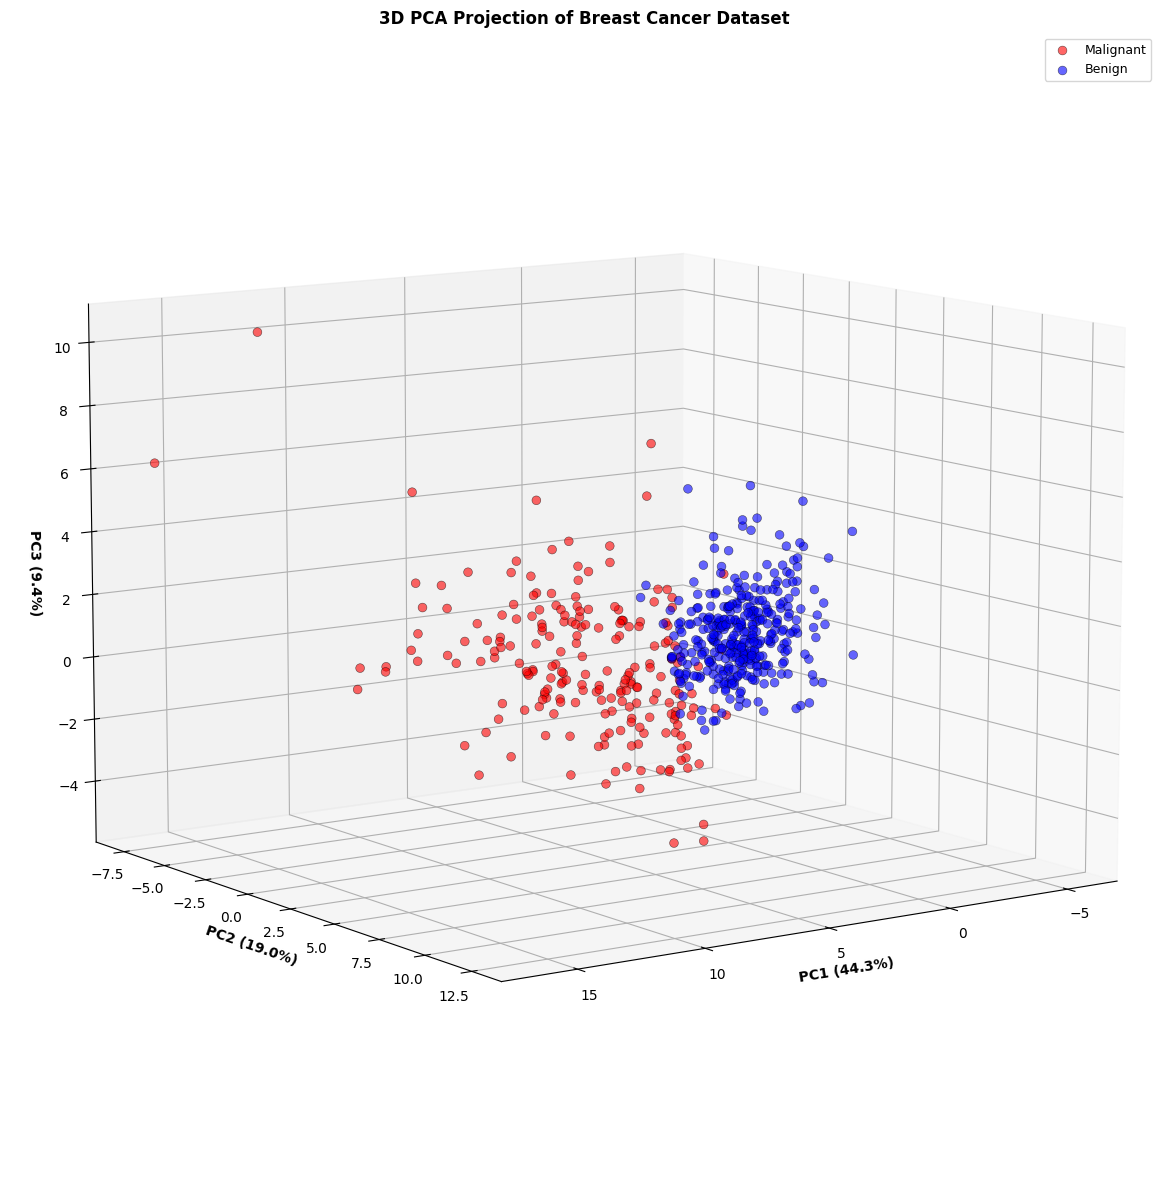

In [28]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection':'3d'})
x_malignant = X_pca_3d[malignant_mask,0] 
y_malignant = X_pca_3d[malignant_mask,1]
z_malignant = X_pca_3d[malignant_mask,2]

x_benign = X_pca_3d[benign_mask,0] 
y_benign = X_pca_3d[benign_mask,1]
z_benign = X_pca_3d[benign_mask,2]

ax.scatter(x_malignant,y_malignant,z_malignant,c='red', alpha=0.6, s=40, label='Malignant',edgecolors='black',linewidth=0.4)
ax.scatter(x_benign,y_benign,z_benign,c='blue', alpha=0.6, s=40, label='Benign',edgecolors='black',linewidth=0.4)

ax.view_init(elev=10, azim=55)
ax.set_xlabel(f'PC1 ({explained_vairance_ratio[0]*100:.1f}%)', fontweight='bold', fontsize=10)
ax.set_ylabel(f'PC2 ({explained_vairance_ratio[1]*100:.1f}%)', fontweight='bold', fontsize=10)
ax.set_zlabel(f'PC3 ({explained_vairance_ratio[2]*100:.1f}%)', fontweight='bold', fontsize=10)
ax.set_title("3D PCA Projection of Breast Cancer Dataset", fontweight='bold', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div class='alert alert-info'>
<u>3D PCA Observations</u>:

From the above 3D PCA projection,we can observe that malignant and bengin samples are fairly well separated in the PCA space, indicating that PCA has effectively captured the variance in the data. This separation suggests that PCA has successfully identified the most important features that differentiate between the two classes.
However, some overlap still exists, indicating that while PCA has improved class separability, it is not perfect. Overall, the 3D PCA projection provides a clearer visualization of the separation between malignant and benign samples compared to the 1D and 2D projections.
</div>